# Model Explainability using SHAP

## Objective

The final selected machine learning model provides accurate predictions for customer churn. However, understanding why the model makes these predictions is equally important for building trust and supporting business decision-making.

This notebook uses **SHAP (SHapley Additive exPlanations)** to interpret the predictions of the final selected model.

The objectives are to:

- Identify the most important features influencing customer churn.
- Understand how each feature affects the prediction.
- Explain the prediction for individual customers.
- Provide business insights from the model explanations.

In [1]:
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
processed_dir = Path("../data/processed")
models_dir = Path("../models")

In [3]:
best_model = joblib.load(
    models_dir / "best_model.pkl"
)

x_train = joblib.load(
    processed_dir / "x_train_processed.pkl"
)

x_test = joblib.load(
    processed_dir / "x_test_processed.pkl"
)

feature_names = joblib.load(
    processed_dir / "feature_names.pkl"
)

In [4]:
feature_names = [
    feature.replace("num__", "")
           .replace("cat__", "")
    for feature in feature_names
]

In [5]:
x_train = pd.DataFrame(
    x_train,
    columns=feature_names
)

x_test = pd.DataFrame(
    x_test,
    columns=feature_names
)

### Observation

The processed feature matrices were converted into pandas DataFrames using the transformed feature names generated by the preprocessing pipeline. This ensures that SHAP visualizations display meaningful feature names, making the explanations easier to interpret.

In [6]:
explainer = shap.TreeExplainer(best_model)


In [7]:
shap_values = explainer(x_test)

### Observation

SHAP values were computed for the test dataset using the final selected XGBoost model. These values quantify the contribution of each feature to the model's prediction for every customer in the test set.

# Global Feature Importance

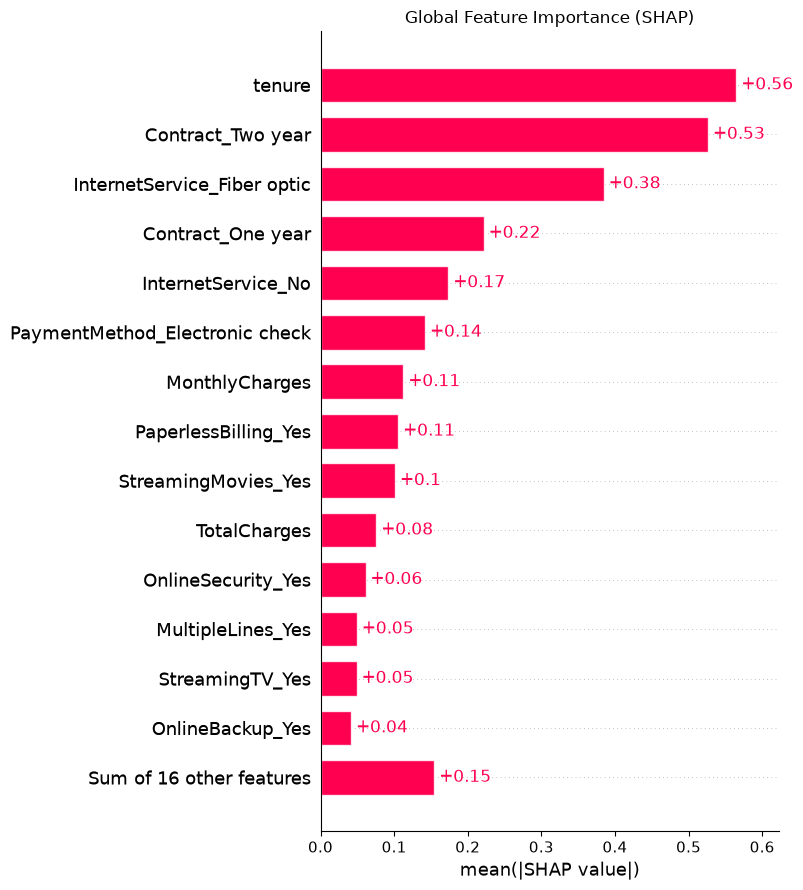

In [ ]:
plt.figure(figsize=(10,6))

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

## Observation

The SHAP feature importance plot ranks the features according to their average contribution to the model's predictions across the entire test dataset.

Features appearing at the top of the chart have the greatest overall influence on customer churn prediction. These features play the most significant role in the decision-making process of the selected XGBoost model.

Unlike traditional feature importance, SHAP importance is calculated from the magnitude of feature contributions across all predictions, providing a more reliable measure of global feature influence.

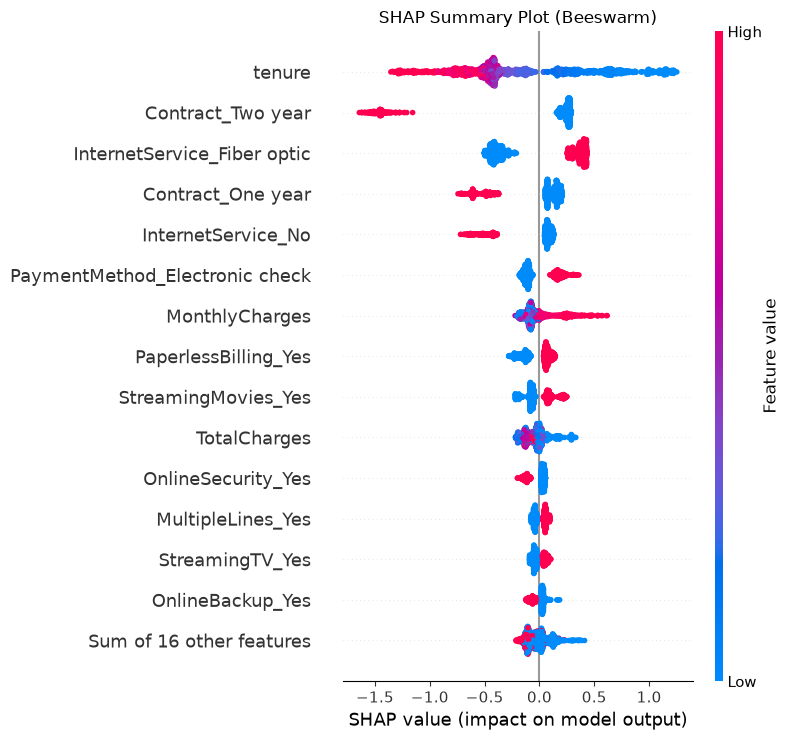

In [11]:
plt.figure(figsize=(12, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot (Beeswarm)")
plt.tight_layout()

plt.show()

## Observation

The SHAP summary plot provides a global explanation of the model by showing how each feature contributes to customer churn predictions across the entire test dataset.

Each point represents a single customer. The horizontal position indicates the impact of the feature on the prediction, while the color represents the feature value (blue for low values and red for high values).

Features at the top have the greatest influence on the model. The distribution of points reveals whether high or low values of a feature increase or decrease the probability of customer churn.

# 9. Waterfall Plot

In [25]:
customer_index = 0

print(f"Customer Index: {customer_index}")
print(f"Predicted Class: {best_model.predict(x_test.iloc[[customer_index]])[0]}")
print(f"Predicted Churn Probability: {best_model.predict_proba(x_test.iloc[[customer_index]])[0,1]:.4f}")

Customer Index: 0
Predicted Class: 0
Predicted Churn Probability: 0.2080


In [26]:

x_test.iloc[customer_index]

tenure                                   1.288198
MonthlyCharges                          -0.696458
TotalCharges                             0.207669
gender_Male                              0.000000
Partner_Yes                              0.000000
Dependents_Yes                           0.000000
PhoneService_Yes                         0.000000
MultipleLines_No phone service           1.000000
MultipleLines_Yes                        0.000000
InternetService_Fiber optic              0.000000
InternetService_No                       0.000000
OnlineSecurity_No internet service       0.000000
OnlineSecurity_Yes                       0.000000
OnlineBackup_No internet service         0.000000
OnlineBackup_Yes                         1.000000
DeviceProtection_No internet service     0.000000
DeviceProtection_Yes                     0.000000
TechSupport_No internet service          0.000000
TechSupport_Yes                          1.000000
StreamingTV_No internet service          0.000000


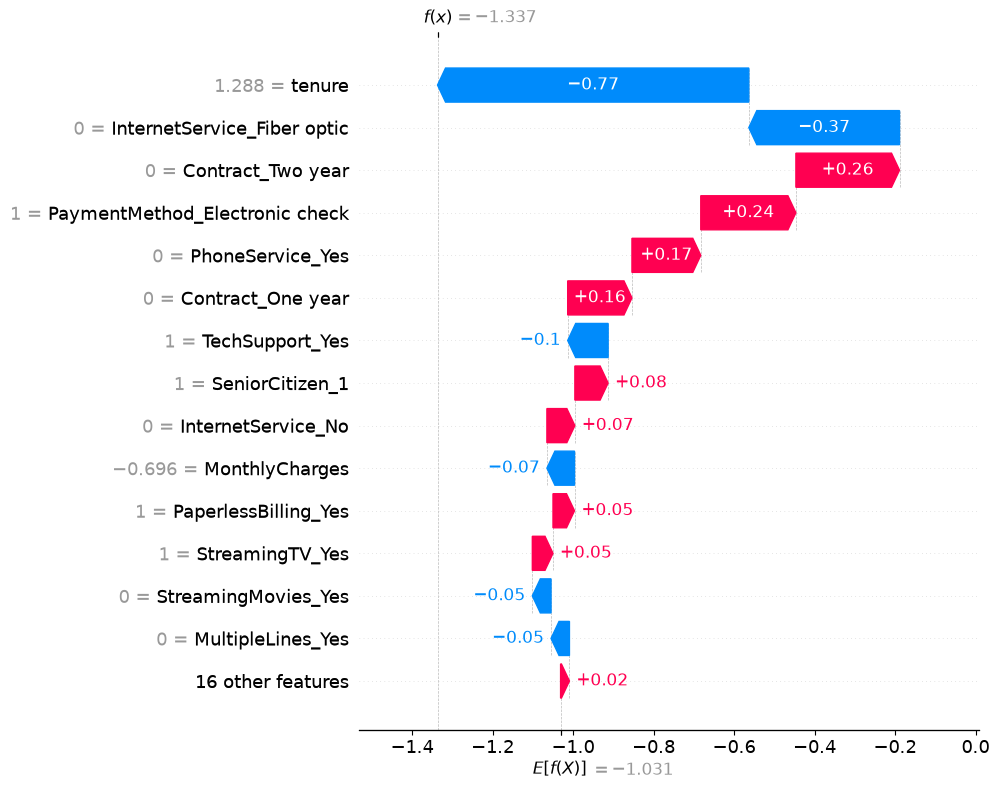

In [27]:
shap.plots.waterfall(
    shap_values[customer_index],
    max_display=15
)

## Observation

The SHAP waterfall plot explains the prediction for a single customer by showing how individual feature contributions move the prediction from the model's baseline output to the final prediction.

Red bars represent features that increase the likelihood of customer churn, while blue bars represent features that decrease it.

The magnitude of each bar indicates the strength of that feature's contribution. This local explanation helps identify the primary factors responsible for the prediction for an individual customer.

# Business Insights

The SHAP analysis provides valuable insights into the factors influencing customer churn predictions made by the final XGBoost model.

### Key Findings

- **Tenure** is the most influential feature. Customers with shorter tenure are significantly more likely to churn, while long-term customers tend to remain loyal.

- **Contract type** plays a major role in customer retention. Customers with one-year and two-year contracts are considerably less likely to churn than customers on month-to-month contracts.

- Customers using **Fiber Optic Internet Service** exhibit a higher likelihood of churn, suggesting the need for further investigation into service quality, pricing, or customer satisfaction.

- Customers with **higher monthly charges** generally show an increased probability of churn.

- Payment through **Electronic Check** is associated with a higher churn risk compared with other payment methods.

### Business Recommendations

Based on these findings, businesses should consider:

- Developing onboarding programs for new customers.
- Encouraging customers to switch from month-to-month contracts to long-term contracts.
- Investigating customer satisfaction among Fiber Optic users.
- Reviewing pricing strategies for customers with high monthly charges.
- Offering personalized retention campaigns for high-risk customers identified by the model.

# Conclusion

This notebook used SHAP (SHapley Additive exPlanations) to interpret the predictions made by the final XGBoost customer churn model.

Global explainability revealed that tenure, contract type, internet service, monthly charges, and payment method are among the most influential factors affecting churn predictions.

Local explainability demonstrated how individual customer characteristics contribute positively or negatively to a specific prediction, providing transparent and interpretable decision-making.

The SHAP analysis enhances trust in the model by explaining both global feature importance and individual customer predictions, making the model suitable for business decision support and integration into the Customer Churn Intelligence Platform.